
# Graph-Masked Self Attention For Multi-Hop Reasoning

**Felix Jeong, Scholar's Elective 2200E**

This notebook implements the experiments for the final presentation, comparing three attention strategies (dense, sliding-window, and graph-structured) on a synthetic $k$-hop reachability task. The goal is to evaluate whether graph-masked attention improves multi-hop reasoning while reducing computational cost.

## Importing Libraries and Connecting to GPU

In [ ]:
#config
import random, time, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from itertools import product
from torch.utils.data import DataLoader
import networkx as nx
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

# ── Plot style ──────────────────────────────────────────────
METHOD_COLORS = {"dense": "#4C72B0", "window": "#DD8452", "graph": "#55A868"}
METHOD_LABELS = {"dense": "Dense", "window": "Window", "graph": "Graph-Masked"}

plt.rcParams.update({
    "figure.facecolor":    "white",
    "axes.facecolor":      "#FAFAFA",
    "axes.edgecolor":      "#CCCCCC",
    "axes.grid":           True,
    "grid.color":          "#E0E0E0",
    "grid.linewidth":      0.6,
    "font.size":           11,
    "axes.titlesize":      13,
    "axes.titleweight":    "bold",
    "axes.labelsize":      11,
    "legend.fontsize":     10,
    "legend.framealpha":   0.9,
    "legend.edgecolor":    "#CCCCCC",
    "lines.linewidth":     2.0,
    "lines.markersize":    6,
    "xtick.direction":     "out",
    "ytick.direction":     "out",
    "figure.dpi":          120,
    "savefig.dpi":         150,
    "savefig.bbox":        "tight",
})

PLOTLY_TEMPLATE = "plotly_white"
PLOTLY_COLORS = {"dense": "#4C72B0", "window": "#DD8452", "graph": "#55A868"}


'cuda'

## Building Synthetic Dataset

We generate a synthetic graph reasoning dataset to compare different attention masks under controlled conditions.

Key choices:

- **Deterministic ground truth:** each example contains a known $k$-hop path
  $v_0 \rightarrow v_1 \rightarrow \cdots \rightarrow v_k$, and the label is $v_k$.

- **Size is guaranteed and generates fast:** instead of rejecting random graphs until constraints are met, we **construct** graphs so the target is well-defined by design. This avoids very slow generation when $k$ and distractors are large.

- **Distractor edges:** we add extra directed edges between **any pair of nodes** (including path nodes), subject to one constraint: no distractor may create an alternative $k$-hop path from start to target. This is verified via BFS on each sample. Distractors touching path nodes eliminate degree-based structural shortcuts that would let a model succeed without genuine multi-hop reasoning.

- **Order invariance:** all edge blocks are shuffled so the model cannot rely on presentation order.

**Encoding**

Each directed edge $(u, v)$ is encoded as **$[U, u, V, v, E]$**.

The query tail is **$[SEP, S, start, k]$**, where **$k$** is a dedicated hop token (e.g., K3) indicating the hop count.

The label is the destination node ID **$v_k$**.


In [ ]:
def build_dataset(n=4000, num_nodes=30, k=3, distractors=40, seed=None, KMAX=8):
    if seed is not None:
        random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

    base = num_nodes
    vocab = {"U": base, "V": base+1, "E": base+2, "SEP": base+3, "S": base+4}
    for i in range(KMAX+1):
        vocab[f"K{i}"] = base + 5 + i
    V = base + 5 + (KMAX+1)

    nodes = list(range(num_nodes))
    data = []

    def _try_one_sample():
        """Attempt to generate one valid sample. Returns (tensor, target) or None."""
        path = random.sample(nodes, k+1)
        true = [(path[i], path[i+1]) for i in range(k)]
        start, target = path[0], path[-1]
        true_set = set(true)

        # Distractors can be ANY edge except true path edges and self-loops
        cand = [(u, v) for u in nodes for v in nodes
                if u != v and (u, v) not in true_set]

        if distractors > len(cand):
            return None

        random.shuffle(cand)
        dist_edges = cand[:distractors]

        # Safety: reject if distractors create an alternative k-hop path to target
        G = nx.DiGraph()
        G.add_edges_from(true + dist_edges)
        for p in nx.all_simple_paths(G, start, target, cutoff=k):
            if len(p) == k + 1 and p != path:
                return None

        edges = true + dist_edges
        blocks = [[vocab["U"], u, vocab["V"], v, vocab["E"]] for (u, v) in edges]
        random.shuffle(blocks)

        x = [t for b in blocks for t in b] + [vocab["SEP"], vocab["S"], start, vocab[f"K{k}"]]
        return (torch.tensor(x, dtype=torch.long), target)

    max_attempts = n * 3
    attempts = 0
    while len(data) < n and attempts < max_attempts:
        attempts += 1
        sample = _try_one_sample()
        if sample is not None:
            data.append(sample)

    if len(data) < n:
        print(f"Warning: only generated {len(data)}/{n} samples after {attempts} attempts (alt-path conflicts)")

    return data, V, vocab


## Visualizing Dataset

Now, we will visualize a sample.

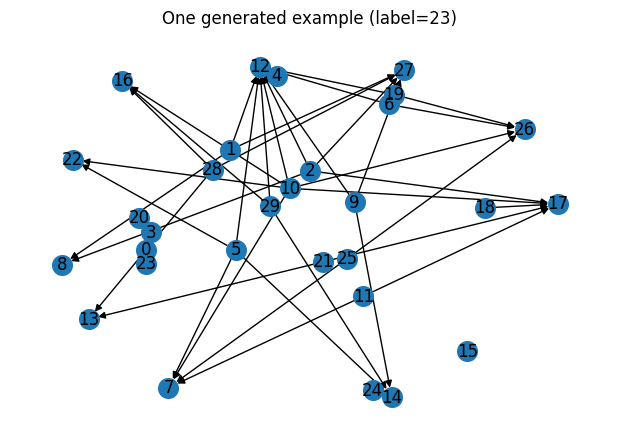

In [ ]:
def decode_edges_from_x(x, vocab):
    """Decode edge list from tokens before SEP. Order is arbitrary (blocks are shuffled in build_dataset)."""
    U, V, E, SEP = vocab["U"], vocab["V"], vocab["E"], vocab["SEP"]
    x = x.tolist()
    sep = x.index(SEP)
    edge_tokens = x[:sep]
    edges = []
    for i in range(0, len(edge_tokens), 5):
        _, u, _, v, _ = edge_tokens[i:i+5]
        edges.append((u, v))
    return edges


def query_start_and_k_from_x(x, vocab):
    """Query tail is [SEP, S, start_node, Kk]. Never infer k from edge list order."""
    x_list = x.tolist() if hasattr(x, "tolist") else list(x)
    sep_idx = x_list.index(vocab["SEP"])
    start_node = x_list[sep_idx + 2]
    k_tok = x_list[sep_idx + 3]
    for name, tid in vocab.items():
        if name.startswith("K") and tid == k_tok:
            return start_node, int(name[1:])
    raise ValueError(f"Unknown hop-count token id {k_tok} in query tail")


# Visualize one sample (keep num_nodes / k in sync with build_dataset)
NUM_NODES, VIZ_K, VIZ_D = 30, 3, 40
data, Vsz, vocab = build_dataset(n=1, num_nodes=NUM_NODES, k=VIZ_K, distractors=VIZ_D, seed=42)
x, y = data[0]
edges = decode_edges_from_x(x, vocab)

G = nx.DiGraph()
G.add_nodes_from(range(NUM_NODES))
G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=42, k=1.5)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_facecolor("white")

start_node, k = query_start_and_k_from_x(x, vocab)

# Recover true path in the graph (NOT edges[:k] — shuffle breaks that)
path_edges = []
for p in nx.all_simple_paths(G, start_node, y, cutoff=k):
    if len(p) == k + 1:
        path_edges = [(p[i], p[i + 1]) for i in range(k)]
        break
if not path_edges:
    print("Warning: no simple path of exactly k edges from start to target; graph may be inconsistent with label.")
other_edges = [e for e in edges if e not in path_edges]

nx.draw_networkx_edges(G, pos, edgelist=other_edges, edge_color="#CCCCCC",
                       arrows=True, arrowsize=12, width=1.0, ax=ax, alpha=0.6)
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color=METHOD_COLORS["graph"],
                       arrows=True, arrowsize=16, width=2.5, ax=ax)

# Nodes: highlight path nodes
path_nodes = set()
for u, v in path_edges:
    path_nodes.add(u); path_nodes.add(v)
node_colors = [METHOD_COLORS["graph"] if n in path_nodes else "#E8E8E8" for n in G.nodes()]
node_edge_colors = ["#333333" if n in path_nodes else "#AAAAAA" for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=300, node_color=node_colors,
                       edgecolors=node_edge_colors, linewidths=1.5, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold",
                        font_color="white", ax=ax)

ax.set_title(f"Sample Graph  (k={k}: {start_node} → … → {y})", pad=12)
ax.axis("off")
plt.tight_layout()
plt.show()


## Train / Validation Split and Data Loading

To evaluate each attention variant fairly, we split the synthetic dataset into two disjoint subsets:

- **Training set:** used to fit model parameters (optimize the loss).
- **Validation set:** held out during training and used to measure generalization (validation accuracy).

We use an **80/20 split** (train/validation). The split is performed after shuffling (with a fixed random seed) so the validation set is not biased by the order examples were generated.

If an experiment mixes multiple values of $k$ (or different distractor counts) in one dataset, we keep the split **balanced across settings** so train and validation have a similar difficulty distribution.

Because each example is constructed with a fixed number of edges and a fixed query tail, every input sequence has the **same length**. This allows us to batch examples efficiently by stacking token sequences into a tensor of shape **(B, L)**, where **B** is the batch size and **L** is the sequence length.

Finally, we create PyTorch **DataLoaders**:
- `train_loader` shuffles batches to improve training stability.
- `val_loader` does not shuffle (order does not matter for evaluation) and can use a larger batch size to speed up validation.

In [ ]:
def split_data(data, val_frac=0.2):
    data = list(data)  # copy to avoid mutating the original list
    random.shuffle(data)
    n = len(data)
    n_val = int(n * val_frac)
    return data[n_val:], data[:n_val]

def collate(batch):
    xs = torch.stack([b[0] for b in batch], dim=0)  # fixed length by construction
    ys = torch.tensor([b[1] for b in batch], dtype=torch.long)
    return xs, ys


## Incorporating Attention Masks (Dense, Local, Graph-Structured)

In standard Transformers, **self-attention is dense**: every token can attend to every other token. In our synthetic graph reasoning setup, this can be wasteful because most tokens (especially distractor edges) are irrelevant to answering the query.

To study how restricting attention affects performance, we compare three masking strategies. Each mask is a Boolean matrix where:

- shape is **(L, L)** (or **(B, L, L)** for per-sample masks),
- **`True` means "blocked"** (attention is not allowed),
- **`False` means "allowed"** (attention is permitted).

**1) Dense attention (baseline):**  
No mask (or all False): every token can attend to every token.

**2) Sliding-window attention (radius=32):**  
Token $i$ may attend to tokens in positions $[i−32, …, i+32]$
- clipped to sequence bounds)

**3) Graph-token mask (graph-structured attention):**  
Sparse mask that reflects the underlying graph structure encoded in tokens:
- tokens within the same edge block **[U, u, V, v, E]** can attend to each other,
- tokens that represent the *same node ID* (shared `u` or `v`) can attend to each other across different edges,
- query tokens (the query tail after `SEP`) can attend to **all node-ID tokens** and to each other (and node-ID tokens can attend back to the query tail).

This creates a **graph-like attention pattern** over the token sequence, aiming to preserve useful message-passing behavior while filtering out irrelevant interactions.

In [ ]:

# dense attention is default, therefore dense mask function is unnecessary

def sliding_window_mask(L, window, device):
    """Vectorized sliding window mask. True = blocked."""
    idx = torch.arange(L, device=device)
    return (idx.unsqueeze(0) - idx.unsqueeze(1)).abs() > window

# Fast graph token mask
# vectorized and cached
_GRAPH_MASK_CACHE = {}

def clear_graph_mask_cache():
    """Clear the mask cache to free memory between runs."""
    _GRAPH_MASK_CACHE.clear()

def graph_token_mask(x, vocab, num_nodes, device):
    B, L = x.shape
    sep_id = vocab["SEP"]

    sep_pos = (x[0] == sep_id).nonzero(as_tuple=False)
    if len(sep_pos) == 0:
        return torch.zeros(B, L, L, dtype=torch.bool, device=device)
    q_start = int(sep_pos[0].item())

    key = (L, q_start, num_nodes, str(device))
    cached = _GRAPH_MASK_CACHE.get(key)

    if cached is None:
        block = 5
        nb = q_start // block
        base = torch.arange(nb, device=device) * block
        node_pos = torch.cat([base + 1, base + 3], dim=0)

        A = torch.zeros(L, L, dtype=torch.bool, device=device)  # True=allowed

        bid = torch.arange(q_start, device=device) // block
        A[:q_start, :q_start] = (bid[:, None] == bid[None, :])

        A[q_start:, q_start:] = True

        A[q_start:, node_pos] = True
        A[node_pos, q_start:] = True

        _GRAPH_MASK_CACHE[key] = (A, node_pos)
    else:
        A, node_pos = cached

    Ab = A.unsqueeze(0).expand(B, -1, -1).clone()

    vals = x[:, node_pos]
    valid = (vals >= 0) & (vals < num_nodes)
    eq = (vals[:, :, None] == vals[:, None, :]) & valid[:, :, None] & valid[:, None, :]

    Ab[:, node_pos.unsqueeze(1), node_pos.unsqueeze(0)] |= eq

    return ~Ab  # True=blocked


### Multi-Hop Graph Mask
Extends the 1-hop graph mask to allow attention within k hops in the graph.
Computes reachability R = A + A² + ... + Aᵏ where A is the adjacency matrix.
This lets a single attention layer see multi-hop neighborhoods.

In [ ]:
def khop_graph_token_mask(x, vocab, num_nodes, device, k_hops=2):
    """Graph mask allowing attention within k hops (not just direct neighbors).
    Computes reachability matrix R = A + A^2 + ... + A^k_hops.
    Tokens whose nodes are within k_hops of each other can attend."""
    B, L = x.shape
    sep_id = vocab["SEP"]

    sep_pos = (x[0] == sep_id).nonzero(as_tuple=False)
    if len(sep_pos) == 0:
        return torch.zeros(B, L, L, dtype=torch.bool, device=device)
    q_start = int(sep_pos[0].item())
    block = 5
    nb_edges = q_start // block

    # Base allowed: same-block tokens + query tokens
    A_base = torch.zeros(L, L, dtype=torch.bool, device=device)
    bid = torch.arange(q_start, device=device) // block
    A_base[:q_start, :q_start] = (bid[:, None] == bid[None, :])
    A_base[q_start:, q_start:] = True
    base_pos = torch.arange(nb_edges, device=device) * block
    node_pos = torch.cat([base_pos + 1, base_pos + 3], dim=0)
    A_base[q_start:, node_pos] = True
    A_base[node_pos, q_start:] = True

    # Build per-sample node adjacency and compute k-hop reachability
    Ab = A_base.unsqueeze(0).expand(B, -1, -1).clone()
    vals = x[:, node_pos]  # (B, num_node_positions)
    valid = (vals >= 0) & (vals < num_nodes)

    # Build adjacency per sample in node-space, then raise to k_hops power
    for b in range(B):
        # Map node positions to node IDs
        node_ids = vals[b]  # (num_node_positions,)
        v = valid[b]
        # Build node-level adjacency (num_nodes x num_nodes)
        adj = torch.zeros(num_nodes, num_nodes, dtype=torch.float32, device=device)
        # Each edge block has src at pos+1, dst at pos+3
        for ei in range(nb_edges):
            src_id = x[b, ei * block + 1].item()
            dst_id = x[b, ei * block + 3].item()
            if 0 <= src_id < num_nodes and 0 <= dst_id < num_nodes:
                adj[src_id, dst_id] = 1.0
                adj[dst_id, src_id] = 1.0  # undirected for attention

        # k-hop reachability: R = A + A^2 + ... + A^k_hops
        reach = adj.clone()
        power = adj.clone()
        for _ in range(k_hops - 1):
            power = power @ adj
            reach = reach + power
        reach = (reach > 0)  # boolean reachability
        # Add self-loops
        reach.fill_diagonal_(True)

        # Map back to token positions
        for i, ni in enumerate(node_pos):
            if not v[i]: continue
            nid_i = node_ids[i].item()
            for j, nj in enumerate(node_pos):
                if not v[j]: continue
                nid_j = node_ids[j].item()
                if reach[nid_i, nid_j]:
                    Ab[b, ni, nj] = True

    return ~Ab  # True=blocked


## Tiny Transformer Baseline

To isolate the performance of selected attention masks (dense, sliding-window, graph-structured), we use a small Transformer model with a fixed architecture across all experiments.

We keep the model lightweight because the comparison is based on **attention connectivity**, not model scale. This is a preliminary experiment with limited compute, and scaling to larger models can be explored in future work.

**Model components**
- **Token embedding**: maps each input token ID to a vector of size $d_{\text{model}}$.
- **Positional embedding**: adds learned position information so the model can distinguish token order in the sequence.
- **Transformer blocks**: a stack of repeated layers, each consisting of:
  - LayerNorm → Multi-Head Self-Attention → residual connection
  - LayerNorm → Feed-Forward network (MLP) → residual connection

**Attention masking**
We optionally provide an `attn_mask` to the attention layer:
- `True` = blocked (token cannot attend to that position)
- `False` = allowed  
This is where we apply **dense (default)**, **sliding window**, or **graph-token** attention patterns while keeping all other model details identical.

**Prediction head**
The model predicts the destination node $v_k$ as a multi-class classification problem over the $N$ possible node IDs. We take the hidden state at the **SEP token** (the boundary between the edge list and the query tail) and apply a linear classifier to output logits of shape $(B, N)$.

In [ ]:

class Block(torch.nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn = torch.nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.ff = torch.nn.Sequential(
            torch.nn.Linear(d_model, 4*d_model),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(4*d_model, d_model),
        )
        self.drop = torch.nn.Dropout(dropout)
        self.ln1 = torch.nn.LayerNorm(d_model)
        self.ln2 = torch.nn.LayerNorm(d_model)

    def forward(self, h, attn_mask=None):
        a,_ = self.attn(h, h, h, attn_mask=attn_mask, need_weights=False)
        h = self.ln1(h + self.drop(a))
        h = self.ln2(h + self.drop(self.ff(h)))
        return h

class TinyModel(torch.nn.Module):
    def __init__(self, V, num_nodes, sep_id, d_model=128, n_heads=4, n_layers=2, max_len=512, dropout=0.1):
        super().__init__()
        self.n_heads = n_heads
        self.sep_id = sep_id
        self.tok = torch.nn.Embedding(V, d_model)
        self.pos = torch.nn.Embedding(max_len, d_model)
        self.drop = torch.nn.Dropout(dropout)
        self.blocks = torch.nn.ModuleList([Block(d_model, n_heads, dropout=dropout) for _ in range(n_layers)])
        self.head = torch.nn.Linear(d_model, num_nodes)

    def forward(self, x, attn_mask=None):
        B, L = x.shape
        pos = torch.arange(L, device=x.device).unsqueeze(0).expand(B, L)
        h = self.drop(self.tok(x) + self.pos(pos))
        for blk in self.blocks:
            h = blk(h, attn_mask=attn_mask)
        sep_pos = (x == self.sep_id).int().argmax(dim=1)
        sep_h = h[torch.arange(B, device=x.device), sep_pos]
        return self.head(sep_h)


In [ ]:
# ── GCN Baseline ──────────────────────────────────────────────────────
# A simple 2-layer Graph Convolutional Network for comparison.
# No external dependencies (no PyG/DGL) — pure PyTorch.
# 
# How it works:
#   1. Each node gets an embedding (its node ID)
#   2. Message passing: H' = ReLU(A_norm @ H @ W)
#   3. After 2 rounds, read out from the start node
#   4. Linear head predicts the target node

class SimpleGCN(nn.Module):
    """Hand-coded 2-layer GCN. No PyG needed."""
    
    def __init__(self, num_nodes=30, d_hidden=128, n_layers=2, dropout=0.1):
        super().__init__()
        self.num_nodes = num_nodes
        self.node_embed = nn.Embedding(num_nodes, d_hidden)
        
        self.convs = nn.ModuleList()
        for _ in range(n_layers):
            self.convs.append(nn.Linear(d_hidden, d_hidden))
        
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(d_hidden, num_nodes)
    
    def forward(self, adj, start_node):
        """
        adj: (B, N, N) float adjacency matrix (can be asymmetric for directed graphs)
        start_node: (B,) int tensor — which node to read out from
        """
        B, N, _ = adj.shape
        
        # Node features = embeddings for nodes 0..N-1
        node_ids = torch.arange(N, device=adj.device)
        H = self.node_embed(node_ids).unsqueeze(0).expand(B, -1, -1)  # (B, N, d)
        
        # Normalize adjacency: A_norm = D^{-1} @ A  (row-normalize)
        # Add self-loops first: A' = A + I
        A = adj + torch.eye(N, device=adj.device).unsqueeze(0)
        deg = A.sum(dim=-1, keepdim=True).clamp(min=1)  # (B, N, 1)
        A_norm = A / deg  # row-normalized
        
        # Message passing
        for conv in self.convs:
            H = A_norm @ H          # aggregate neighbors: (B, N, d)
            H = conv(H)             # linear transform
            H = F.relu(H)
            H = self.dropout(H)
        
        # Read out from start node
        idx = start_node.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, H.size(-1))  # (B, 1, d)
        h_start = H.gather(1, idx).squeeze(1)  # (B, d)
        
        return self.head(h_start)  # (B, num_nodes) — logits over target node

## Training and Evaluation Loop for Single Attention Variant

Next, we define the training and evaluation logic used to test each attention strategy under the same model and optimization settings.

We focus on the following:
- **One method at a time:** `train_one(...)` trains a new `TinyModel` using a chosen attention rule (`method`).
- **Shared objective:** the model predicts the destination node $v_k$ (multi-class classification over node IDs), trained with **cross-entropy loss**.
- **Consistent comparison:** only the **attention mask** changes across methods; the architecture, dataset, and optimizer remain fixed.

**Mask handling**
- Dense attention uses `attn_mask=None` (default full attention).
- Sliding-window attention uses a single precomputed **(L, L)** mask shared across all batches.
- Graph attention uses a **per-batch (B, L, L)** mask because node IDs differ per sample. Since PyTorch `MultiheadAttention` expects per-example masks in a head-expanded format, we replicate the mask across heads to shape **(B · H, L, L)**.

**Evaluation** \
`eval_acc(...)` computes validation accuracy by taking `argmax` over the output logits. To ensure a fair comparison across methods, validation is performed using the **same attention rule as training** (dense/window/graph).

In [ ]:
def expand_mask_for_heads(m, h):
    B, L, _ = m.shape
    return m.unsqueeze(1).expand(B, h, L, L).reshape(B * h, L, L)

_USE_AMP = device == "cuda"

@torch.no_grad()
def eval_acc(model, loader, method, vocab=None, num_nodes=None, window=32,
             max_batches=None, cached_win=None, graph_mask_fn=None):
    _mask_fn = graph_mask_fn or graph_token_mask
    model.eval(); x0, _ = next(iter(loader)); L = x0.shape[1]
    win = cached_win if cached_win is not None else (sliding_window_mask(L, window, device=device) if method == "window" else None)
    c = t = 0
    for bi, (x, y) in enumerate(loader):
        if max_batches is not None and bi >= max_batches: break
        x, y = x.to(device), y.to(device)
        if method == "dense": attn = None
        elif method == "window": attn = win
        elif method == "graph": attn = expand_mask_for_heads(_mask_fn(x, vocab, num_nodes, device=device), model.n_heads)
        else: raise ValueError(method)
        with torch.cuda.amp.autocast(enabled=_USE_AMP):
            p = model(x, attn_mask=attn).argmax(-1)
        c += (p == y).sum().item(); t += y.numel()
    return c / t if t else float("nan")


def train_one(method, num_nodes, vocab, V, train_loader, val_loader,
              n_layers=2, d_model=128, n_heads=4, dropout=0.1,
              window=32, epochs=20, lr=1e-3,
              eval_every=1, eval_val_batches=None,
              patience=5, min_delta=1e-4, mask_stats_batches=4,
              label_smoothing=0.05, warmup_epochs=3, graph_mask_fn=None):

    _mask_fn = graph_mask_fn or graph_token_mask

    model = TinyModel(V, num_nodes, sep_id=vocab["SEP"],
                      d_model=d_model, n_heads=n_heads,
                      n_layers=n_layers, dropout=dropout).to(device)

    # torch.compile for PyTorch 2.x on CUDA
    if device == "cuda" and hasattr(torch, "compile"):
        try:
            model = torch.compile(model)
        except Exception:
            pass  # fallback gracefully

    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    scaler = torch.cuda.amp.GradScaler(enabled=_USE_AMP)

    # linear warmup then cosine decay
    def lr_lambda(ep):
        if ep < warmup_epochs:
            return (ep + 1) / warmup_epochs
        progress = (ep - warmup_epochs) / max(1, epochs - warmup_epochs)
        return 0.5 * (1 + math.cos(math.pi * progress))
    scheduler = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)

    x0, _ = next(iter(train_loader)); L = x0.shape[1]
    win = sliding_window_mask(L, window, device=device) if method == "window" else None

    best = 0.0; bad = 0; hist = []
    gsum = 0.0; gn = 0

    for ep in range(1, epochs + 1):
        t0 = time.time(); model.train()
        esum = en = 0.0

        for bi, (x, y) in enumerate(train_loader):
            x, y = x.to(device), y.to(device)
            if method == "dense": attn = None
            elif method == "window": attn = win
            elif method == "graph":
                m = _mask_fn(x, vocab, num_nodes, device=device)
                if bi < mask_stats_batches: esum += (~m).float().mean().item(); en += 1
                attn = expand_mask_for_heads(m, model.n_heads)
            else: raise ValueError(method)

            with torch.cuda.amp.autocast(enabled=_USE_AMP):
                loss = F.cross_entropy(model(x, attn_mask=attn), y, label_smoothing=label_smoothing)

            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()

        scheduler.step()

        if method == "graph" and en: gsum += esum; gn += en

        if (ep % eval_every) == 0 or ep == epochs:
            tr = eval_acc(model, train_loader, method, vocab=vocab, num_nodes=num_nodes, window=window, max_batches=10, cached_win=win, graph_mask_fn=_mask_fn)
            va = eval_acc(model, val_loader,   method, vocab=vocab, num_nodes=num_nodes, window=window, max_batches=eval_val_batches, cached_win=win, graph_mask_fn=_mask_fn)
            hist.append((ep, tr, va))

            if va > best + min_delta: best, bad = va, 0
            else: bad += 1

            cur_lr = scheduler.get_last_lr()[0]
            print(f"{method} ep{ep}: train_acc={tr:.3f} | val_acc={va:.3f} | best={best:.3f} | bad={bad}/{patience} | lr={cur_lr:.5f} | epoch_time={time.time()-t0:.1f}s")

            if bad >= patience:
                print(f"{method} early stop @ ep{ep} (best={best:.3f})")
                break

    if method == "dense":
        allowed_pct = 100.0; print("dense allowed ≈ 100.0%")
    elif method == "window":
        allowed_pct = 100 * (~win).float().mean().item()
        print(f"window allowed ≈ {allowed_pct:.1f}%")
    else:
        allowed_pct = 100 * (gsum / max(gn, 1))
        print(f"graph allowed (sampled) ≈ {allowed_pct:.1f}% [sampled {mask_stats_batches} batches/epoch]")

    final_full = eval_acc(model, val_loader, method, vocab=vocab, num_nodes=num_nodes, window=window, max_batches=None, cached_win=win, graph_mask_fn=_mask_fn)
    print(f"{method} FINAL full-val acc = {final_full:.3f}")
    return model, best, final_full, allowed_pct, hist


In [ ]:
# ── GCN Training Infrastructure ──────────────────────────────────────

def tokens_to_graph(x, vocab, num_nodes):
    """Convert a batch of token sequences to (adj, start_node) for GCN.
    x: (B, L) token tensor
    Returns: adj (B, N, N) float, start_node (B,) long
    """
    B, L = x.shape
    sep_id = vocab["SEP"]
    adj = torch.zeros(B, num_nodes, num_nodes, dtype=torch.float32, device=x.device)
    start_nodes = torch.zeros(B, dtype=torch.long, device=x.device)

    for b in range(B):
        seq = x[b]
        sep_pos = (seq == sep_id).nonzero(as_tuple=False)
        if len(sep_pos) == 0:
            continue
        q_start = sep_pos[0].item()

        # Extract edges from 5-token blocks: [U, src, V, dst, E]
        for i in range(0, q_start, 5):
            src = seq[i + 1].item()
            dst = seq[i + 3].item()
            if 0 <= src < num_nodes and 0 <= dst < num_nodes:
                adj[b, src, dst] = 1.0
                adj[b, dst, src] = 1.0  # undirected for GCN

        # Start node is at SEP+2: [SEP, S, start_node, Kk]
        start_nodes[b] = seq[q_start + 2].item()

    return adj, start_nodes


def collate_gcn(batch, vocab, num_nodes):
    """Collate function that converts token batches to GCN inputs."""
    xs = torch.stack([b[0] for b in batch], dim=0)
    ys = torch.tensor([b[1] for b in batch], dtype=torch.long)
    adj, start = tokens_to_graph(xs, vocab, num_nodes)
    return adj, start, ys


@torch.no_grad()
def eval_gcn_acc(model, loader, max_batches=None):
    model.eval()
    c = t = 0
    for bi, (adj, start, y) in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break
        adj, start, y = adj.to(device), start.to(device), y.to(device)
        with torch.cuda.amp.autocast(enabled=_USE_AMP):
            p = model(adj, start).argmax(-1)
        c += (p == y).sum().item()
        t += y.numel()
    return c / t if t else float("nan")


def train_gcn(num_nodes, train_loader, val_loader,
              d_hidden=128, n_layers=2, dropout=0.1,
              epochs=20, lr=1e-3,
              eval_every=1, eval_val_batches=None,
              patience=5, min_delta=1e-4,
              label_smoothing=0.05, warmup_epochs=3):
    """Train a SimpleGCN with the same schedule as train_one."""

    model = SimpleGCN(num_nodes=num_nodes, d_hidden=d_hidden,
                      n_layers=n_layers, dropout=dropout).to(device)

    if device == "cuda" and hasattr(torch, "compile"):
        try:
            model = torch.compile(model)
        except Exception:
            pass

    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    scaler = torch.cuda.amp.GradScaler(enabled=_USE_AMP)

    def lr_lambda(ep):
        if ep < warmup_epochs:
            return (ep + 1) / warmup_epochs
        progress = (ep - warmup_epochs) / max(1, epochs - warmup_epochs)
        return 0.5 * (1 + math.cos(math.pi * progress))
    scheduler = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)

    best = 0.0; bad = 0; hist = []

    for ep in range(1, epochs + 1):
        t0 = time.time(); model.train()

        for adj, start, y in train_loader:
            adj, start, y = adj.to(device), start.to(device), y.to(device)

            with torch.cuda.amp.autocast(enabled=_USE_AMP):
                logits = model(adj, start)
                loss = F.cross_entropy(logits, y, label_smoothing=label_smoothing)

            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()

        scheduler.step()

        if (ep % eval_every) == 0 or ep == epochs:
            tr = eval_gcn_acc(model, train_loader, max_batches=10)
            va = eval_gcn_acc(model, val_loader, max_batches=eval_val_batches)
            hist.append((ep, tr, va))

            if va > best + min_delta: best, bad = va, 0
            else: bad += 1

            cur_lr = scheduler.get_last_lr()[0]
            print(f"gcn ep{ep}: train_acc={tr:.3f} | val_acc={va:.3f} | best={best:.3f} | bad={bad}/{patience} | lr={cur_lr:.5f} | epoch_time={time.time()-t0:.1f}s")

            if bad >= patience:
                print(f"gcn early stop @ ep{ep} (best={best:.3f})")
                break

    final_full = eval_gcn_acc(model, val_loader, max_batches=None)
    print(f"gcn FINAL full-val acc = {final_full:.3f}")
    return model, best, final_full, hist


def run_with_gcn(k=3, distractors=40, num_nodes=30, n=4000,
                 n_layers=2, d_model=128, n_heads=4, dropout=0.1,
                 epochs=20, lr=1e-3, window=32, patience=7, seed=42,
                 eval_every=1, eval_val_batches=None, fast=False,
                 gcn_layers=None):
    """Run all 3 Transformer methods + GCN baseline on the same data.
    Delegates Transformer runs to run_three(), then adds GCN on the same split.
    """
    # Run the 3 Transformer methods via run_three (single source of truth)
    results = run_three(
        k=k, distractors=distractors, num_nodes=num_nodes, n=n,
        n_layers=n_layers, d_model=d_model, n_heads=n_heads, dropout=dropout,
        epochs=epochs, lr=lr, window=window, patience=patience, seed=seed,
        eval_every=eval_every, eval_val_batches=eval_val_batches, fast=fast
    )

    # Reproduce the exact same split that run_three used
    _gcn_layers = gcn_layers if gcn_layers is not None else max(k, n_layers)
    if fast:
        epochs = min(epochs, 10)
        patience = min(patience, 3)
        eval_every = max(eval_every, 3)
        eval_val_batches = eval_val_batches or 5

    data, V, vocab = get_dataset(n, num_nodes, k, distractors, seed)
    random.seed(seed)  # reset so split_data reproduces the same shuffle as in run_three
    train, val = split_data(data, 0.2)
    _pin = (device == "cuda")

    print(f"\n== gcn (n_layers={_gcn_layers}) ==")
    gcn_collate = lambda batch: collate_gcn(batch, vocab, num_nodes)
    gcn_train_loader = DataLoader(train, batch_size=64, shuffle=True, collate_fn=gcn_collate,
                                  pin_memory=_pin, num_workers=0)
    gcn_val_loader = DataLoader(val, batch_size=128, shuffle=False, collate_fn=gcn_collate,
                                pin_memory=_pin, num_workers=0)

    gcn_model, gcn_best, gcn_final, gcn_hist = train_gcn(
        num_nodes, gcn_train_loader, gcn_val_loader,
        d_hidden=d_model, n_layers=_gcn_layers, dropout=dropout,
        epochs=epochs, lr=lr,
        eval_every=eval_every, eval_val_batches=eval_val_batches,
        patience=patience
    )
    results["gcn"] = {
        "best": gcn_best, "final_full": gcn_final,
        "allowed_pct": 0.0, "hist": gcn_hist
    }

    return results


def plot_comparison(results, title_suffix=""):
    """Training curves for all methods including GCN."""
    fig, ax = plt.subplots(figsize=(9, 5))
    gcn_color = "#C44E52"
    all_methods = [m for m in ("dense", "window", "graph", "gcn") if m in results]
    colors = {**METHOD_COLORS, "gcn": gcn_color}
    labels = {**METHOD_LABELS, "gcn": "GCN"}

    for m in all_methods:
        h = results[m]["hist"]
        if not h: continue
        e  = [t[0] for t in h]
        va = [t[2] for t in h]
        tr = [t[1] for t in h]
        c = colors[m]
        ax.plot(e, va, marker="o", color=c, label=f"{labels[m]} (val)", markersize=5)
        ax.plot(e, tr, marker=".", linestyle="--", color=c, alpha=0.45,
                label=f"{labels[m]} (train)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title(f"Transformer vs GCN{title_suffix}")
    ax.legend(loc="upper left", ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_comparison_bar(results, title_suffix=""):
    """Bar chart of final accuracy for all methods including GCN."""
    gcn_color = "#C44E52"
    all_methods = [m for m in ("dense", "window", "graph", "gcn") if m in results]
    colors = {**METHOD_COLORS, "gcn": gcn_color}
    labels = {**METHOD_LABELS, "gcn": "GCN"}

    accs = [results[m]["final_full"] for m in all_methods]
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar([labels[m] for m in all_methods], accs,
                  color=[colors[m] for m in all_methods], edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylabel("Validation Accuracy")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title(f"Final Accuracy: Transformer Methods vs GCN{title_suffix}")
    plt.tight_layout()
    plt.show()

## Running the Three Baselines for a Single Configuration

We will now run a complete experiment for one dataset setting defined by hop count $k$ and the number of distractor edges:

1. **Generate synthetic data:** create $n$ examples with a fixed graph size (`num_nodes`) and a valid $k$-hop query. Each example includes a unique correct target $v_k$ (deterministic ground truth) and `distractors` additional edges.
2. **Split train/validation:** randomly split the dataset into 80% training and 20% validation.
3. **Create loaders:** build PyTorch `DataLoader`s to batch examples efficiently.
4. **Train three attention variants:** train the same Tiny Transformer under each attention strategy:
   - **dense** (full attention),
   - **window** (sliding-window attention),
   - **graph** (graph-token mask attention).
5. **Collect results:** compute validation accuracy for each method and return a dictionary of accuracies (best and final full-validation).

In [ ]:
# Dataset cache: avoids regenerating data for repeated configs
_DATASET_CACHE = {}

def clear_dataset_cache():
    """Clear cached datasets (call after modifying build_dataset)."""
    _DATASET_CACHE.clear()

def get_dataset(n, num_nodes, k, distractors, seed):
    """Cached dataset builder. Returns (data, V, vocab)."""
    key = (n, num_nodes, k, distractors, seed)
    if key not in _DATASET_CACHE:
        _DATASET_CACHE[key] = build_dataset(n=n, num_nodes=num_nodes, k=k, distractors=distractors, seed=seed)
    return _DATASET_CACHE[key]


def run_three(k=3, distractors=40, num_nodes=30, n=4000,
              n_layers=2, d_model=128, n_heads=4, dropout=0.1,
              epochs=20, lr=1e-3,
              window=32, patience=7, seed=42,
              eval_every=1, eval_val_batches=None,
              fast=False, graph_mask_fn=None):
    """Run all 3 attention methods. fast=True uses aggressive early stopping for sweeps.
    graph_mask_fn: optional custom mask function for the 'graph' method (default: graph_token_mask).
    """
    clear_graph_mask_cache()
    # Note: dataset cache is NOT cleared here (intentional — reuses data for speed).
    # Call clear_dataset_cache() manually if you modified build_dataset().

    # Fast mode: fewer epochs, less frequent eval, quicker early stopping
    if fast:
        epochs = min(epochs, 10)
        patience = min(patience, 3)
        eval_every = max(eval_every, 3)
        eval_val_batches = eval_val_batches or 5

    data, V, vocab = get_dataset(n, num_nodes, k, distractors, seed)

    random.seed(seed)  # ensure split is deterministic even when dataset is cached
    train, val = split_data(data, 0.2)
    _pin = (device == "cuda")
    train_loader = DataLoader(train, batch_size=64, shuffle=True,  collate_fn=collate,
                              pin_memory=_pin, num_workers=2, persistent_workers=True)
    val_loader   = DataLoader(val,   batch_size=128, shuffle=False, collate_fn=collate,
                              pin_memory=_pin, num_workers=2, persistent_workers=True)

    L = next(iter(train_loader))[0].shape[1]
    if n_layers is None: n_layers = 2

    mode_str = "FAST" if fast else "FULL"
    print(f"Config [{mode_str}]:", {"k":k, "distractors":distractors, "L":L, "V":V, "num_nodes":num_nodes, "n":len(data),
                     "window":window, "n_layers":n_layers, "d_model":d_model, "n_heads":n_heads, "dropout":dropout,
                     "epochs":epochs, "patience":patience, "eval_every":eval_every})

    results = {"_L": L}
    for method in ("dense","window","graph"):
        print("\n==", method, "==")
        model, best_va, final_full, allowed_pct, hist = train_one(
            method, num_nodes, vocab, V, train_loader, val_loader,
            n_layers=n_layers, d_model=d_model, n_heads=n_heads, dropout=dropout,
            window=window, epochs=epochs, lr=lr,
            eval_every=eval_every, eval_val_batches=eval_val_batches,
            patience=patience, graph_mask_fn=graph_mask_fn
        )
        results[method] = {
            "best": best_va, "final_full": final_full,
            "allowed_pct": allowed_pct, "hist": hist
        }
    return results


### Note

The output prints **graph allowed (sampled)** once per run (per method). This reports the average fraction of token-to-token attention connections that are **allowed** by the graph-token mask.

For example, if **graph allowed (sampled) = 4.5%**, then only **4.5%** of token pairs are allowed to attend and **95.5%** are blocked by the mask. In contrast, dense attention allows every token to attend to every token (**≈ 100%** allowed).

Because the graph mask depends on the node IDs in each batch, this percentage is **sampled** by averaging over a fixed number of batches per epoch (e.g., the first 4 batches), and then averaged across epochs.

In [ ]:
def plot_hist(results, title_suffix=""):
    """Training curves: train (dashed) and val (solid) accuracy per method."""
    fig, ax = plt.subplots(figsize=(9, 5))
    for m in ("dense", "window", "graph"):
        h = results[m]["hist"]
        if not h: continue
        e  = [t[0] for t in h]
        tr = [t[1] for t in h]
        va = [t[2] for t in h]
        c = METHOD_COLORS[m]
        ax.plot(e, va, marker="o", color=c, label=f"{METHOD_LABELS[m]} (val)", markersize=5)
        ax.plot(e, tr, marker=".", linestyle="--", color=c, alpha=0.45,
                label=f"{METHOD_LABELS[m]} (train)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title(f"Training & Validation Accuracy{title_suffix}")
    ax.legend(loc="upper left", ncol=2)
    plt.tight_layout()
    plt.show()


def plot_best_so_far(results, title_suffix=""):
    """Monotonically increasing best validation accuracy per method."""
    fig, ax = plt.subplots(figsize=(9, 5))
    for m in ("dense", "window", "graph"):
        h = results[m]["hist"]
        if not h: continue
        e  = [t[0] for t in h]
        va = [t[2] for t in h]
        best = []
        cur = -1.0
        for a in va:
            cur = max(cur, a)
            best.append(cur)
        ax.plot(e, best, marker="o", color=METHOD_COLORS[m],
                label=METHOD_LABELS[m], markersize=5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Best Val Accuracy")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title(f"Convergence (Best So Far){title_suffix}")
    ax.legend()
    plt.tight_layout()
    plt.show()


def measure_shortcut_baselines(num_nodes=30, k=3, distractors_list=(20, 40, 80),
                                n_samples=2000, seed=42):
    """Measure accuracy of non-learning heuristic shortcuts on the dataset.
    Returns a dict mapping distractors -> {random, dst_only, lowest_deg}."""
    from collections import Counter
    baselines = {}
    for d in distractors_list:
        random.seed(seed); np.random.seed(seed)
        nodes = list(range(num_nodes))
        dst_only_acc = 0.0
        lowest_deg_acc = 0.0
        accepted = 0
        attempts = 0
        while accepted < n_samples and attempts < n_samples * 3:
            attempts += 1
            path = random.sample(nodes, k + 1)
            true = [(path[i], path[i + 1]) for i in range(k)]
            start, target = path[0], path[-1]
            true_set = set(true)
            cand = [(u, v) for u in nodes for v in nodes
                    if u != v and (u, v) not in true_set]
            random.shuffle(cand)
            dist_edges = cand[:d]
            G = nx.DiGraph()
            G.add_edges_from(true + dist_edges)
            has_alt = False
            for p in nx.all_simple_paths(G, start, target, cutoff=k):
                if len(p) == k + 1 and p != path:
                    has_alt = True
                    break
            if has_alt:
                continue
            accepted += 1
            all_edges = true + dist_edges
            src_c = Counter(e[0] for e in all_edges)
            dst_c = Counter(e[1] for e in all_edges)
            total_c = Counter()
            for e in all_edges:
                total_c[e[0]] += 1
                total_c[e[1]] += 1
            cands1 = [v for v in nodes if src_c.get(v, 0) == 0
                       and dst_c.get(v, 0) >= 1 and v != start]
            if target in cands1:
                dst_only_acc += 1.0 / len(cands1)
            min_deg = min(total_c.get(v, 0) for v in nodes if v != start)
            cands2 = [v for v in nodes
                       if total_c.get(v, 0) == min_deg and v != start]
            if target in cands2:
                lowest_deg_acc += 1.0 / len(cands2)
        baselines[d] = {
            "random": 1.0 / num_nodes,
            "dst_only": dst_only_acc / n_samples,
            "lowest_deg": lowest_deg_acc / n_samples,
        }
    return baselines


def plot_accuracy_vs_shortcuts(results_by_d, baselines, num_nodes=30,
                                title="Model Accuracy vs Heuristic Shortcuts"):
    """Bar chart: for each distractor level, show random baseline, best shortcut,
    and each trained model's accuracy. The gap above the shortcut is genuine reasoning."""
    ds = sorted(results_by_d.keys())
    methods = [m for m in ("dense", "window", "graph", "gcn") if m in results_by_d[ds[0]]]
    n_bars = 2 + len(methods)  # random + best_shortcut + each method
    x = np.arange(len(ds))
    w = 0.8 / n_bars

    fig, ax = plt.subplots(figsize=(10, 5.5))
    gcn_color = "#C44E52"
    colors = {**METHOD_COLORS, "gcn": gcn_color}
    labels = {**METHOD_LABELS, "gcn": "GCN"}

    # Random baseline
    rand_vals = [baselines[d]["random"] for d in ds]
    ax.bar(x - 0.4 + w * 0.5, rand_vals, w, color="#AAAAAA", label="Random (1/N)")

    # Best shortcut
    short_vals = [max(baselines[d]["dst_only"], baselines[d]["lowest_deg"]) for d in ds]
    ax.bar(x - 0.4 + w * 1.5, short_vals, w, color="#E0B040",
           label="Best Heuristic Shortcut", edgecolor="#B08020", linewidth=0.8)

    for i, m in enumerate(methods):
        vals = [results_by_d[d][m]["final_full"] for d in ds]
        ax.bar(x - 0.4 + w * (2.5 + i), vals, w,
               color=colors[m], label=labels[m])

    ax.set_xticks(x)
    ax.set_xticklabels([f"d={d}" for d in ds])
    ax.set_xlabel("Number of Distractor Edges")
    ax.set_ylabel("Accuracy")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8.5)
    ax.axhline(y=1.0 / num_nodes, color="#AAAAAA", linestyle=":", linewidth=0.8)
    plt.tight_layout()
    plt.show()


def grid_run(ks=(2,3,4,5), ds=(20,40,80), n_grid=1500, epochs=12, window=32):
    rows = []
    for k in ks:
        for d in ds:
            seed = 1234 + 100*k + d
            random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

            nodes = 30 if k <= 3 else 50

            r = run_three(
                k=k, distractors=d, num_nodes=nodes, n=n_grid,
                epochs=epochs, window=window, seed=seed,
                eval_every=1, eval_val_batches=None,
                fast=True,
            )

            L = r.get("_L", 5*(k + d) + 4)

            for method in ("dense","window","graph"):
                rows.append({
                    "k": k, "distractors": d, "num_nodes": nodes, "L": L,
                    "method": method,
                    "best_acc": r[method]["best"],
                    "final_acc": r[method]["final_full"],
                    "allowed_pct": r[method]["allowed_pct"],
                })
    return pd.DataFrame(rows)



In [ ]:
# ── Main experiment: k=3, d=40 ──
res = run_three(k=3, distractors=40, n=8000, epochs=30, eval_every=1, eval_val_batches=None, patience=10)
plot_hist(res, "  (k=3, d=40)")
plot_best_so_far(res, "  (k=3, d=40)")

# ── Grid sweep across k and distractor levels ──
df = grid_run()
df

### Hyperparameter Sweep & Dataset Scaling
Sweep one hyperparameter at a time while holding others fixed.
Then test whether accuracy scales with dataset size.

In [ ]:
def hp_sweep(base_config, param_name, values, seeds=[42], fast=True):
    """Sweep one hyperparameter while holding others fixed."""
    results = []
    for val in values:
        config = {**base_config, param_name: val}
        for seed in seeds:
            r = run_three(**config, seed=seed, fast=fast)
            for method in ["dense", "window", "graph"]:
                results.append({
                    param_name: val, "seed": seed, "method": method,
                    "best_acc": r[method]["best"], "allowed_pct": r[method]["allowed_pct"]
                })
    return pd.DataFrame(results)


def plot_sweep(df, param_name):
    """Plot accuracy vs parameter value for each method."""
    fig, ax = plt.subplots(figsize=(8, 5))
    for method in ["dense", "window", "graph"]:
        sub = df[df["method"] == method]
        grouped = sub.groupby(param_name)["best_acc"].agg(["mean", "std"]).reset_index()
        ax.errorbar(grouped[param_name], grouped["mean"], yerr=grouped["std"],
                    marker="o", color=METHOD_COLORS[method],
                    label=METHOD_LABELS[method], capsize=4, capthick=1.5)
    ax.set_xlabel(param_name)
    ax.set_ylabel("Best Val Accuracy")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title(f"Accuracy vs {param_name}")
    ax.legend()
    plt.tight_layout()
    plt.show()


# Base config for sweeps
BASE = dict(k=3, distractors=40, num_nodes=30, n=4000, epochs=20, lr=1e-3, window=32, patience=7)

# Uncomment each sweep one at a time to run:
# df_dmodel = hp_sweep(BASE, "d_model", [64, 128, 256]); plot_sweep(df_dmodel, "d_model")
# df_layers = hp_sweep(BASE, "n_layers", [2, 3, 4]); plot_sweep(df_layers, "n_layers")
# df_drop = hp_sweep(BASE, "dropout", [0.0, 0.1, 0.2]); plot_sweep(df_drop, "dropout")
# df_heads = hp_sweep(BASE, "n_heads", [2, 4, 8]); plot_sweep(df_heads, "n_heads")

# After finding best config, confirm with 5 seeds:
# BEST = dict(k=3, distractors=40, num_nodes=30, n=4000, epochs=20, lr=1e-3, window=32, patience=7,
#             d_model=128, n_heads=4, n_layers=2, dropout=0.1)
# df_confirm = hp_sweep(BEST, "n", [4000], seeds=[0,1,2,3,4])

# Dataset size scaling:
# df_size = hp_sweep(BEST, "n", [4000, 10000, 20000]); plot_sweep(df_size, "n")


### Attention Visualization
Extract and plot attention weight heatmaps for each method on the same input.
Shows where each method focuses attention — graph mask should concentrate on path-relevant edges.

In [ ]:
def get_attention_weights(model, x, method, vocab, num_nodes, window=32, graph_mask_fn=None):
    """Extract attention weights from first layer for visualization."""
    _mask_fn = graph_mask_fn or graph_token_mask
    model.eval()
    with torch.no_grad():
        B, L = x.shape
        pos = torch.arange(L, device=x.device).unsqueeze(0).expand(B, L)
        h = model.drop(model.tok(x) + model.pos(pos))
        if method == "dense":
            mask = None
        elif method == "window":
            mask = sliding_window_mask(L, window, x.device)
        else:
            mask = _mask_fn(x, vocab, num_nodes, device=x.device)
            mask = expand_mask_for_heads(mask, model.n_heads)
        block = model.blocks[0]
        attn_out, attn_weights = block.attn(h, h, h, attn_mask=mask,
                                            need_weights=True, average_attn_weights=True)
    return attn_weights  # (B, L, L)


def plot_attention_comparison(models, sample_x, vocab, num_nodes, window=32, crop=60, graph_mask_fn=None):
    """Side-by-side attention heatmaps for all three methods."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    x = sample_x.unsqueeze(0).to(device) if sample_x.dim() == 1 else sample_x[:1].to(device)

    for ax, method in zip(axes, ["dense", "window", "graph"]):
        model = models[method]
        weights = get_attention_weights(model, x, method, vocab, num_nodes, window,
                                            graph_mask_fn=graph_mask_fn)
        w = weights[0].cpu().numpy()
        c = min(crop, w.shape[0])
        im = ax.imshow(w[:c, :c], cmap="magma", aspect="auto", vmin=0)
        ax.set_title(METHOD_LABELS[method], fontsize=13, fontweight="bold")
        ax.set_xlabel("Key Position", fontsize=10)
        ax.set_ylabel("Query Position", fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle("Attention Weights  (Layer 1, first {0} tokens)".format(c),
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("attention_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to attention_comparison.png")


# Usage: pass a dict of trained models + a sample input tensor
# plot_attention_comparison(models_dict, sample_x[0], vocab, num_nodes)


### Higher Hop Counts (k=4, k=5)
Test whether graph masking helps for deeper multi-hop reasoning.
Key: n_layers should be >= k so info can propagate across the full path.

In [ ]:
# Scale to higher k — match n_layers to k for fair comparison
# Uncomment to run:

# print("=== k=4 ===")
# res_k4 = run_three(k=4, distractors=40, num_nodes=50, n=4000,
#                    n_layers=4, epochs=30, patience=10, seed=42)
# plot_hist(res_k4, "  (k=4, d=40)")

# print("=== k=5 ===")
# res_k5 = run_three(k=5, distractors=40, num_nodes=50, n=4000,
#                    n_layers=5, epochs=30, patience=10, seed=42)
# plot_hist(res_k5, "  (k=5, d=40)")

# For multi-hop mask comparison at k=4, see run_multihop_comparison() in the next cell.


In [ ]:
# ── Multi-Hop Mask Comparison (k=4) ───────────────────────────────────
# Compares different (hop_range, n_layers) combos for graph-masked attention.
# Hypothesis: wider hop range can compensate for fewer layers.

from functools import partial

def run_multihop_comparison(n=4000, num_nodes=50, k=4, distractors=40,
                            seeds=range(3), epochs=20, fast=False):
    """Compare 1-hop/4-layer vs 2-hop/2-layer vs 4-hop/1-layer graph masks."""
    configs = [
        {"label": "1-hop + 4 layers", "k_hops": 1, "n_layers": 4},
        {"label": "2-hop + 2 layers", "k_hops": 2, "n_layers": 2},
        {"label": "4-hop + 1 layer",  "k_hops": 4, "n_layers": 1},
    ]
    
    all_results = []
    for cfg in configs:
        print(f"\n{'='*60}")
        print(f"  {cfg['label']}  (k_hops={cfg['k_hops']}, n_layers={cfg['n_layers']})")
        print(f"{'='*60}")
        
        # Create a partial mask function with the right k_hops
        if cfg['k_hops'] == 1:
            mfn = graph_token_mask  # standard 1-hop
        else:
            mfn = partial(khop_graph_token_mask, k_hops=cfg['k_hops'])
        
        seed_results = []
        for s in seeds:
            r = run_three(n=n, num_nodes=num_nodes, k=k, distractors=distractors,
                          seed=s, epochs=epochs, n_layers=cfg['n_layers'],
                          graph_mask_fn=mfn, fast=fast)
            seed_results.append(r)
        
        # Average across seeds
        avg = {}
        for method in ['dense', 'window', 'graph']:
            accs = [sr[method]["final_full"] for sr in seed_results if method in sr]
            if accs:
                avg[method] = sum(accs) / len(accs)
        
        all_results.append({
            "label": cfg['label'],
            "k_hops": cfg['k_hops'],
            "n_layers": cfg['n_layers'],
            "avg_acc": avg,
            "per_seed": seed_results
        })
        
        print(f"  Avg accuracy -> Dense: {avg.get('dense',0):.3f}  "
              f"Window: {avg.get('window',0):.3f}  "
              f"Graph: {avg.get('graph',0):.3f}")
    
    return all_results

def plot_multihop_comparison(results):
    """Bar chart comparing multi-hop configurations."""
    labels = [r['label'] for r in results]
    methods = ['dense', 'window', 'graph']
    x = np.arange(len(labels))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for i, method in enumerate(methods):
        vals = [r['avg_acc'].get(method, 0) for r in results]
        bars = ax.bar(x + i * width, vals, width, label=METHOD_LABELS[method],
                      color=METHOD_COLORS[method], edgecolor='white', linewidth=0.5)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.1%}', ha='center', va='bottom', fontsize=9,
                    fontweight='bold')
    
    ax.set_xlabel('Configuration')
    ax.set_ylabel('Accuracy')
    ax.set_title('Multi-Hop Mask Comparison (k=4, 40 distractors)')
    ax.set_xticks(x + width)
    ax.set_xticklabels(labels)
    ax.legend()
    ax.set_ylim(0, max(0.15, max(r['avg_acc'].get('graph', 0) for r in results) * 1.3))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    
    plt.tight_layout()
    plt.savefig('multihop_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── Run (uncomment to execute on Colab) ──
# multihop_results = run_multihop_comparison(fast=True)  # fast for initial test
# plot_multihop_comparison(multihop_results)
# 
# Full run with more seeds:
# multihop_results = run_multihop_comparison(seeds=range(5), fast=False)
# plot_multihop_comparison(multihop_results)

### GCN Baseline Comparison
Compare the three Transformer attention strategies against a simple Graph Convolutional Network.
The GCN gets the raw adjacency matrix (a structural advantage), while Transformers must extract structure from the token sequence.

In [ ]:
# ── GCN Baseline Experiment ──
# Uncomment to run on Colab:

# gcn_res = run_with_gcn(k=3, distractors=40, n=4000, epochs=20,
#                        n_layers=2, d_model=128, patience=7, seed=42)
# plot_comparison(gcn_res, "  (k=3, d=40)")
# plot_comparison_bar(gcn_res, "  (k=3, d=40)")

# Multi-seed GCN comparison:
# gcn_rows = []
# for s in range(5):
#     r = run_with_gcn(k=3, distractors=40, n=4000, epochs=20, seed=s, patience=7)
#     for m in ["dense", "window", "graph", "gcn"]:
#         gcn_rows.append({"seed": s, "method": m,
#                          "best_acc": r[m]["best"], "final_acc": r[m]["final_full"]})
# df_gcn = pd.DataFrame(gcn_rows)
# print(df_gcn.groupby("method")[["best_acc", "final_acc"]].agg(["mean", "std"]))

### Note on `distractors = 0`

When `distractors = 0`, the sequence is very short and contains only the true path edges.  
This makes the task much easier than the distractor settings, so accuracies can be very high (sometimes near 1.0).

Also, if the sequence length `L` is smaller than the sliding window size, the window mask becomes equivalent to dense attention (≈ 100% allowed).  
For the main comparisons, we focus on `distractors > 0`, where irrelevant context is present.

In [ ]:
SEEDS = [0,1,2,3,4]
DISTRACTORS = [20,40,80]
k = 3

rows = []
for d in DISTRACTORS:
    per_method = {m: {"acc": [], "allowed": []} for m in ["dense","window","graph"]}
    for s in SEEDS:
        res = run_three(k=k, distractors=d, num_nodes=30, n=4000, n_layers=2, epochs=20, lr=1e-3, window=32, seed=s)
        for m in ["dense","window","graph"]:
            per_method[m]["acc"].append(res[m]["final_full"])
            per_method[m]["allowed"].append(res[m]["allowed_pct"])
    rows.append({
        "distractors": d,
        "dense_acc_mean": np.mean(per_method["dense"]["acc"]),
        "window_acc_mean": np.mean(per_method["window"]["acc"]),
        "graph_acc_mean": np.mean(per_method["graph"]["acc"]),
        "dense_allowed_mean": np.mean(per_method["dense"]["allowed"]),
        "window_allowed_mean": np.mean(per_method["window"]["allowed"]),
        "graph_allowed_mean": np.mean(per_method["graph"]["allowed"]),
    })

rows

### Accuracy vs Heuristic Shortcuts

To verify that trained models are genuinely reasoning rather than exploiting structural patterns in the dataset, we compare each model's accuracy against two non-learning baselines:

- **Random guess:** $1/N$ (3.3% for 30 nodes)
- **Best heuristic shortcut:** the better of "pick the destination-only node" and "pick the lowest-degree node" — strategies that exploit node degree patterns without any multi-hop reasoning

The gap between a model's bar and the shortcut bar represents **genuine reasoning** that cannot be explained by structural artifacts.

In [ ]:
# Compute heuristic shortcut baselines for the same distractor levels
shortcut_baselines = measure_shortcut_baselines(num_nodes=30, k=3,
                                                 distractors_list=DISTRACTORS)

# Collect trained model results by distractor level (from the multi-seed experiment above)
# Average across seeds for each method
results_by_d = {}
for d_idx, d in enumerate(DISTRACTORS):
    results_by_d[d] = {}
    for m in ["dense", "window", "graph"]:
        col = f"{m}_acc_mean"
        results_by_d[d][m] = {"final_full": rows[d_idx][col]}

plot_accuracy_vs_shortcuts(results_by_d, shortcut_baselines, num_nodes=30,
                            title="Trained Model Accuracy vs Heuristic Shortcuts  (k=3, 5 seeds)")

In [ ]:
def pareto_plot(df):
    """Scatter: accuracy vs attention connectivity for all grid configs."""
    fig, ax = plt.subplots(figsize=(9, 6))
    for m in ["dense", "window", "graph"]:
        sub = df[df["method"] == m]
        ax.scatter(sub["allowed_pct"], sub["final_acc"], s=70,
                   color=METHOD_COLORS[m], label=METHOD_LABELS[m],
                   edgecolors="white", linewidths=0.5, zorder=3)
    ax.set_xlabel("Allowed Attention Connections (%)")
    ax.set_ylabel("Validation Accuracy")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title("Accuracy vs Attention Connectivity")
    ax.legend()
    plt.tight_layout()
    plt.show()


def surface_plot(df, method="graph"):
    """3D surface: accuracy by (k, distractors) for one method."""
    sub = df[df["method"] == method].pivot(index="k", columns="distractors", values="final_acc")
    X, Y = sub.columns.values, sub.index.values
    Z = sub.values
    fig = go.Figure(data=[go.Surface(
        x=X, y=Y, z=Z,
        colorscale="Viridis", opacity=0.9,
        contours=dict(z=dict(show=True, usecolormap=True, highlightcolor="limegreen", project_z=True)),
    )])
    fig.update_layout(
        title=f"Accuracy Surface: {METHOD_LABELS.get(method, method)}",
        template=PLOTLY_TEMPLATE,
        scene=dict(xaxis_title="Distractors", yaxis_title="k (hops)", zaxis_title="Val Accuracy"),
        margin=dict(l=0, r=0, t=40, b=0),
    )
    fig.show()


def winner_heatmap(df):
    """Heatmap showing which method wins at each (k, distractors) config."""
    pivot = df.pivot_table(index=["k", "distractors"], columns="method", values="final_acc").reset_index()
    pivot["winner"] = pivot[["dense", "window", "graph"]].idxmax(axis=1)
    cmap_winner = ListedColormap([METHOD_COLORS["dense"], METHOD_COLORS["window"], METHOD_COLORS["graph"]])
    map_id = {"dense": 0, "window": 1, "graph": 2}
    mat = pivot.assign(wid=pivot["winner"].map(map_id)).pivot(index="k", columns="distractors", values="wid").sort_index()

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.imshow(mat.values, aspect="auto", cmap=cmap_winner, vmin=0, vmax=2)
    ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(mat.index)
    ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns)
    ax.set_xlabel("Distractors"); ax.set_ylabel("k (hops)")
    ax.set_title("Winning Method by Configuration")
    legend_patches = [mpatches.Patch(color=METHOD_COLORS[m], label=METHOD_LABELS[m]) for m in ["dense", "window", "graph"]]
    ax.legend(handles=legend_patches, loc="upper left")
    for i, k_val in enumerate(mat.index):
        for j, d_val in enumerate(mat.columns):
            winner_method = pivot[(pivot["k"] == k_val) & (pivot["distractors"] == d_val)]["winner"].values[0]
            acc = pivot[(pivot["k"] == k_val) & (pivot["distractors"] == d_val)][winner_method].values[0]
            ax.text(j, i, f"{acc:.1%}", ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    plt.tight_layout()
    plt.show()


def line_plot(df, fixed_col, fixed_val, x_col, title_suffix=""):
    """Line plot: accuracy vs one variable, holding another fixed."""
    sub = df[df[fixed_col] == fixed_val].sort_values(x_col)
    fig, ax = plt.subplots(figsize=(8, 5))
    for method in ["dense", "window", "graph"]:
        md = sub[sub["method"] == method]
        ax.plot(md[x_col], md["final_acc"], marker="o", color=METHOD_COLORS[method],
                label=METHOD_LABELS[method])
    ax.set_xlabel(x_col)
    ax.set_ylabel("Validation Accuracy")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title(f"Accuracy vs {x_col}{title_suffix}")
    if x_col == "k":
        ax.set_xticks(sub[x_col].unique())
    ax.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
# All plots use `df` from grid_run() in the earlier cell
pareto_plot(df)
surface_plot(df, "graph")
winner_heatmap(df)
line_plot(df, "distractors", 40, "k", "  (distractors = 40)")
line_plot(df, "k", 4, "distractors", "  (k = 4)")

# Interactive Pareto (Plotly)
fig = px.scatter(
    df, x="allowed_pct", y="final_acc", color="method",
    color_discrete_map=PLOTLY_COLORS,
    hover_data=["k", "distractors", "L", "num_nodes"],
    labels={"allowed_pct": "Allowed Connections (%)", "final_acc": "Val Accuracy", "method": "Method"},
    title="Accuracy vs Attention Connectivity",
    template=PLOTLY_TEMPLATE,
)
fig.update_traces(marker=dict(size=10, line=dict(width=1, color="white")))
fig.show()

### Export results (agents / reports)

Run this after `grid_run()` and the multi-seed / shortcut cells so **`results/`** contains CSV/JSON you can commit or paste into **Claude Code**, **Cursor**, etc. See `results/README.md`, root **`CLAUDE.md`**, and **`AGENTS.md`**.

In [ ]:
# ── Export results → results/ (Claude Code / Cursor / git / final report) ──
from pathlib import Path
import json
import pandas as pd

OUT = Path("results")
OUT.mkdir(parents=True, exist_ok=True)

if "df" in globals() and df is not None and len(df):
    df.to_csv(OUT / "grid_run.csv", index=False)
    print("Wrote results/grid_run.csv")
else:
    print("Skip grid_run.csv (df missing or empty — run grid_run() first)")

if "rows" in globals() and rows:
    pd.DataFrame(rows).to_csv(OUT / "multiseed_k3_summary.csv", index=False)
    print("Wrote results/multiseed_k3_summary.csv")
else:
    print("Skip multiseed_k3_summary.csv (rows missing — run multi-seed cell first)")

if "shortcut_baselines" in globals() and shortcut_baselines:
    with open(OUT / "shortcut_baselines.json", "w") as f:
        json.dump({str(k): v for k, v in shortcut_baselines.items()}, f, indent=2)
    print("Wrote results/shortcut_baselines.json")
else:
    print("Skip shortcut_baselines.json (optional — run measure_shortcut_baselines cell first)")